In [1]:
from IPython.display import display, Markdown

display(Markdown("""
# 📊 Customer Lifetime Value Prediction Project

### Project Steps

**Data loading** ✔️  
**EDA (shape, info, describe, missing values)** ✔️  
**Duplicate removal** ✔️  
**Outlier handling** ✔️  
**Feature engineering** ✔️  
**Encoding** ✔️  
**Train-test split** ✔️  
**Scaling** ✔️  
**Model training (Linear + Random Forest)** ✔️  
**Evaluation metrics (MAE, RMSE, R²)** ✔️  
**Best model selection** ✔️  
**Interpretation (coefficients)** ✔️  
"""))


# 📊 Customer Lifetime Value Prediction Project

### Project Steps

**Data loading** ✔️  
**EDA (shape, info, describe, missing values)** ✔️  
**Duplicate removal** ✔️  
**Outlier handling** ✔️  
**Feature engineering** ✔️  
**Encoding** ✔️  
**Train-test split** ✔️  
**Scaling** ✔️  
**Model training (Linear + Random Forest)** ✔️  
**Evaluation metrics (MAE, RMSE, R²)** ✔️  
**Best model selection** ✔️  
**Interpretation (coefficients)** ✔️  


In [4]:
import pandas as pd

In [56]:
df=pd.read_csv("C:/Users/Bhagyashree/Downloads/customer_lifetime_value_dataset_10002_rows.csv")

In [58]:
df.shape

(10002, 11)

In [59]:
df.head(1)

,Customer_ID,Age,Annual_Income,Membership_Years,Total_Orders,Avg_Order_Value,Website_Visits_Monthly,Customer_Lifetime_Value,Membership_Type,Customer_Segment,Region
0,1001,56.0,951433.0,11.0,31.0,10446.0,40.0,459678,Gold,New,East


In [64]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              10002 non-null  int64  
 1   Age                      9998 non-null   float64
 2   Annual_Income            9998 non-null   float64
 3   Membership_Years         9998 non-null   float64
 4   Total_Orders             9998 non-null   float64
 5   Avg_Order_Value          9999 non-null   float64
 6   Website_Visits_Monthly   9999 non-null   float64
 7   Customer_Lifetime_Value  10002 non-null  int64  
 8   Membership_Type          9999 non-null   object 
 9   Customer_Segment         9999 non-null   object 
 10  Region                   10002 non-null  object 
dtypes: float64(6), int64(2), object(3)
memory usage: 859.7+ KB


In [65]:
df.describe()


,Customer_ID,Age,Annual_Income,Membership_Years,Total_Orders,Avg_Order_Value,Website_Visits_Monthly,Customer_Lifetime_Value
count,10002.000000,9998.000000,9.998000e+03,9998.000000,9998.000000,9999.000000,9999.000000,10002.000000
mean,5992.201860,44.015203,8.782203e+05,7.496999,99.757051,7836.364436,49.959196,451664.445711
std,2882.877004,15.208338,3.592953e+05,4.638706,57.219552,4185.753513,29.135997,136043.228982
min,1001.000000,18.000000,2.500370e+05,0.000000,1.000000,500.000000,1.000000,69101.000000
25%,3494.250000,31.000000,5.661122e+05,3.000000,50.000000,4221.000000,25.000000,353691.750000
50%,5993.500000,44.000000,8.800885e+05,7.000000,100.000000,7945.000000,50.000000,452531.500000
75%,8488.750000,57.000000,1.186709e+06,12.000000,149.000000,11467.000000,75.000000,549365.500000
max,10982.000000,70.000000,1.499801e+06,15.000000,200.000000,14996.000000,100.000000,834341.000000


In [66]:
df.isnull().sum()

Customer_ID                0
Age                        4
Annual_Income              4
Membership_Years           4
Total_Orders               4
Avg_Order_Value            3
Website_Visits_Monthly     3
Customer_Lifetime_Value    0
Membership_Type            3
Customer_Segment           3
Region                     0
dtype: int64

In [67]:
df = df.drop_duplicates()

In [68]:
#OUTLIER REMOVAL (BEFORE PIPELINE)
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

In [69]:
numeric_cols = [
    "Age",
    "Annual_Income",
    "Membership_Years",
    "Total_Orders",
    "Avg_Order_Value",
    "Website_Visits_Monthly",
    "Customer_Lifetime_Value"
]

for col in numeric_cols:
    df = remove_outliers(df, col)

In [71]:
#FEATURE ENGINEERING##
df["Income_per_Order"] = df["Annual_Income"] / df["Total_Orders"].replace(0, 1)
df["Engagement_Score"] = (df["Website_Visits_Monthly"] * df["Membership_Years"]) / df["Membership_Years"].max()


In [72]:
#ENCODING CATEGORICAL VARIABLES
df = pd.get_dummies(
    df,
    columns=["Membership_Type","Customer_Segment","Region"],
    drop_first=True
)


In [73]:
df.head(5)

,Customer_ID,Age,Annual_Income,Membership_Years,Total_Orders,Avg_Order_Value,Website_Visits_Monthly,Customer_Lifetime_Value,Income_per_Order,Engagement_Score,Membership_Type_Gold,Membership_Type_Premium,Customer_Segment_Regular,Customer_Segment_VIP,Region_North,Region_South,Region_West
0,1001,56.0,951433.0,11.0,31.0,10446.0,40.0,459678,30691.387097,29.333333,True,False,False,False,False,False,False
1,1002,69.0,737947.0,10.0,162.0,3479.0,36.0,491954,4555.228395,24.000000,False,True,False,False,False,True,False
2,1003,46.0,908210.0,11.0,7.0,14887.0,28.0,443014,129744.285714,20.533333,True,False,False,True,False,False,True
3,1004,32.0,409472.0,5.0,144.0,4105.0,64.0,313306,2843.555556,21.333333,False,False,True,False,False,False,False
4,1005,60.0,1048385.0,8.0,150.0,921.0,83.0,585952,6989.233333,44.266667,False,True,True,False,False,False,False


In [79]:
df.shape

(9960, 17)

In [80]:
#DROP UNNECESSARY COLUMN
df.drop("Customer_ID", axis=1, inplace=True)


In [21]:
#SPLIT FEATURES & TARGet col
X = df.drop("Customer_Lifetime_Value", axis=1)
y = df["Customer_Lifetime_Value"]


In [82]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [83]:
#SCALING (AFTER OUTLIERS + SPLIT — CORRECT WAY)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [84]:
#MODEL 1 — LINEAR REGRESSION
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
prediction=lr.predict

In [85]:
#MODEL 2 — RANDOM FOREST (BEST MODEL)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [86]:
#MODEL EVALUATION
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, y_test, y_pred):
    print(f"--- {name} ---")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("\n")

In [87]:
#Evaluate both models:
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)

--- Linear Regression ---
MAE: 25282.592766160196
RMSE: 29089.296444413467
R2 Score: 0.9530589539009101


--- Random Forest ---
MAE: 26776.0174748996
RMSE: 31434.09755481336
R2 Score: 0.9451864005210049




In [88]:
#BEST MODEL SELECTION
import numpy as np
from sklearn.metrics import r2_score

models = ["Linear Regression", "Random Forest"]

scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf)
]

print("Best Model:", models[np.argmax(scores)])

Best Model: Linear Regression


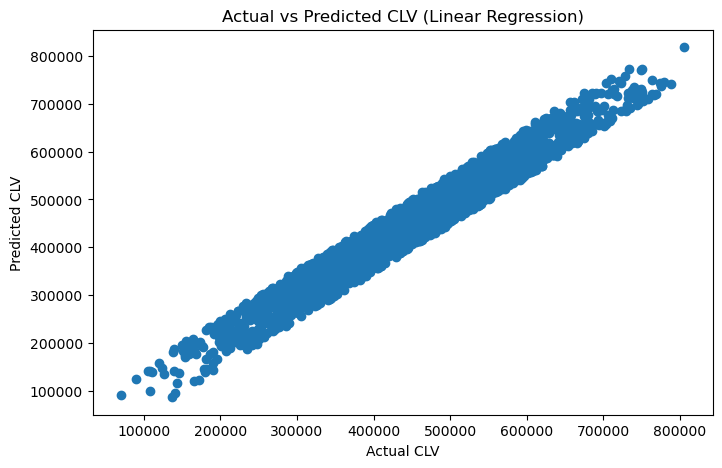

In [89]:
#ACTUAL VS PREDICTED (IMPORTANT VISUAL)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV (Linear Regression)")
plt.show()

In [90]:
#FEATURE IMPORTANCE


lr_feature_weight = pd.DataFrame({
    "Feature": X.columns,
    "Weight": lr.coef_
}).sort_values(by="Weight", ascending=False)

print(lr_feature_weight)

                     Feature        Weight
1              Annual_Income  90193.539858
2           Membership_Years  70495.631288
3               Total_Orders  68920.509435
5     Website_Visits_Monthly    521.324944
11      Customer_Segment_VIP     67.317176
4            Avg_Order_Value     49.764301
0                        Age    -43.053854
12              Region_North   -112.446022
6           Income_per_Order   -150.594100
8       Membership_Type_Gold   -302.467343
14               Region_West   -337.784481
9    Membership_Type_Premium   -459.637847
13              Region_South   -472.000582
10  Customer_Segment_Regular   -474.329738
7           Engagement_Score   -596.834214


In [91]:
from IPython.display import display, Markdown

display(Markdown("""
# 📊 Model Insights (CLV Prediction)

## 🎯 Top Drivers of CLV:
- Income (strongest)  
- Membership duration  
- Purchase frequency  

## 📉 Weak Influence:
- Region  
- Engagement score  
- Membership categories  
"""))


# 📊 Model Insights (CLV Prediction)

## 🎯 Top Drivers of CLV:
- Income (strongest)  
- Membership duration  
- Purchase frequency  

## 📉 Weak Influence:
- Region  
- Engagement score  
- Membership categories  


In [99]:
new_customer = pd.DataFrame([{
    "Age":60,
    "Annual_Income":1000000,
    "Membership_Years":3,
    "Total_Orders":50,
    "Avg_Order_Value":250,
    "Website_Visits_Monthly":15,
    "Membership_Type_Premium":1,
    "Customer_Segment_Business":0,
    "Region_West":1
}])

In [100]:
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

In [101]:
new_customer_scaled = scaler.transform(new_customer)

In [102]:
prediction = lr.predict(new_customer_scaled)
print("Predicted CLV:", prediction[0])

Predicted CLV: 353479.85360381065
